# Visualize U-Net predictions

This notebook loads a released model bundle and demonstrates the reusable map panels in `mindthegap.viz`. Evaluation over many dates belongs in `4-U-Net_Evaluation.ipynb`.

In [17]:
%pip install -e ..

%load_ext autoreload
%autoreload 2

import mindthegap as mtg
print(mtg.__file__)

Obtaining file:///home/jovyan/mindthegap
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mindthegap (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.2.0-0.editable-py3-none-any.whl size=5701 sha256=b4e3e076b6c64ab3c76d774f4a7f7edd6b851733f73a7270f4d27d60a2c46e3d
  Stored in directory: /tmp/pip-ephem-wheel-cache-_3iort5e/wheels/bf/33/56/bda8a265cbf6abb8b49f20ef4e8f99a5cafc428b704405201e
Successfully built mindthegap
  Attempting uninstall: mindthegap
    Found existing installation: mindthegap 0.2.0
    Uninstalling mindthegap-0.2.0:
      Successfully uninstalled mindthegap-0.2.0
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/jovyan/mindthegap/mindthegap/__init__.

In [1]:
import matplotlib.pyplot as plt
import mindthegap as mtg
from mindthegap import viz

## Load a model bundle

Use a local bundle directory or a Hugging Face repository ID. The metadata supplies the exact channel order and standardization needed for prediction.

In [2]:
from pathlib import Path

bundle_source = "../models/io-shared-public-unet-bundle"

if Path(bundle_source).is_dir():
    bundle_path = Path(bundle_source)
else:
    from huggingface_hub import snapshot_download
    bundle_path = Path(snapshot_download(repo_id=bundle_source))

model, metadata = mtg.load_model_bundle(bundle_path)
input_vars = [item["name"] for item in metadata["inputs"]]
print(f"Loaded: {metadata['model']['name']}")
print(f"Inputs: {input_vars}")

2026-08-09 09:02:46.052301: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-09 09:02:46.066510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786266166.084894   41050 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786266166.091285   41050 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786266166.105569   41050 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Data loaded for this model with: demo_data(dataset='io-shared-public', region='indian ocean', time_slice=slice('01-01-2000', '12-31-2000'))
Loaded: IO rechunkded in shared-public U-Net gap filler
Inputs: ['observed_target', 'observed_target_m1', 'observed_target_p1', 'day_sin', 'day_cos', 'estimate_flag', 'unavailable_flag', 'observed_flag', 'land_flag']


## Prepare a gap-fill dataset

Rebuild the training configuration from the bundle with `mtg.options_from_bundle`, then run `build_standardized_lazy(..., mode="gapfill")`. Gap-fill mode reuses the recorded standardization and produces the inference channels (no synthetic clouds), so the inputs match the trained model exactly. For another bundle, replace `mtg.demo_data` with the matching dataset loader recorded in `model_metadata.yaml`.

In [3]:
# Rebuild the exact data configuration used to train this model.
options = mtg.options_from_bundle(metadata)

ds, _ = mtg.demo_data(
    dataset="io-shared-public",
    region=options.data.region_name,
    time_slice=slice(
        *metadata["dataset"]["training_period"].split(" to ")
    ),
)
ds = mtg.crop_to_multiple(ds, multiple=8)

# Gap-fill mode: no synthetic clouds, reuses the recorded standardization.
ds_std, _ = mtg.build_standardized_lazy(ds, options, mode="gapfill")

missing_inputs = [name for name in input_vars if name not in ds_std]
if missing_inputs:
    raise ValueError(
        f"Prepared dataset is missing bundle inputs: {missing_inputs}"
    )
ds_std

Channels created (9 total):
  1. observed_target
  2. observed_target_m1
  3. observed_target_p1
  4. day_sin
  5. day_cos
  6. estimate_flag
  7. unavailable_flag
  8. observed_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (60, 60, 60, 60, 60, 60, 5), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})


<xarray.Dataset> Size: 412MB
Dimensions:             (time: 365, lat: 168, lon: 240)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2000-01-01 ... 2000-12-31
  * lat                 (lat) float32 672B 30.0 29.75 29.5 ... -11.5 -11.75
  * lon                 (lon) float32 960B 42.0 42.25 42.5 ... 101.2 101.5 101.8
Data variables:
    full_target         (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_target     (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_target_m1  (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_target_p1  (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    day_sin             (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    day_cos             (time, lat, lon) float32 59MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    estimate_flag       (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    unavailable_flag    (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    observed_flag       (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
    land_flag           (time, lat, lon) int8 15MB dask.array<chunksize=(60, 64, 64), meta=np.ndarray>
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_end:               2024-04-18T02:58:23Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-04-16T21:12:05Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0

## Observed vs. gap-filled (standardized space)

`mtg.gapfill_std` is a low-level function: it returns the raw model output as an `xarray.Dataset` with a `gapfilled_target` variable in the model's **standardized** space (no unstandardizing or de-logging). Here we plot the standardized observed field beside it. Recovering the original units is the job of the higher-level `gapfill(ds)` (a later function).

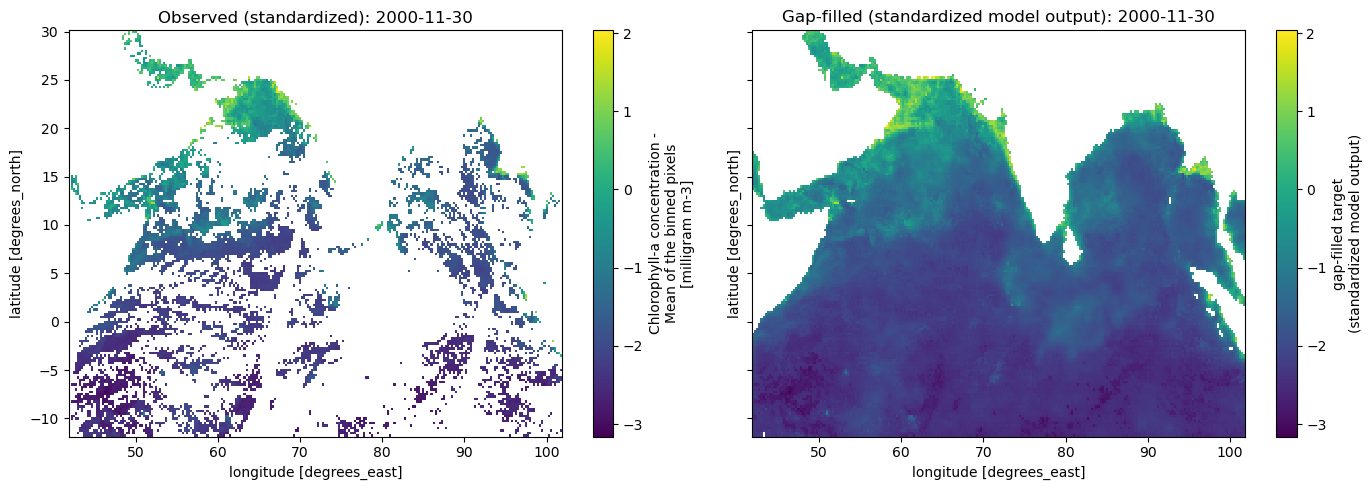

In [10]:
date = "2000-11-30"

gapfilled = mtg.gapfill_std(ds_std, model, metadata, time=date)
prediction = gapfilled["gapfilled_target"].isel(time=0)
observed = ds_std["observed_target"].sel(time=date)

# mask land
land = ds_std["land_flag"].sel(time=date)
observed = observed.where(land == 0)
prediction = prediction.where(land == 0)

vmin = float(min(observed.min(), prediction.min()))
vmax = float(max(observed.max(), prediction.max()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
observed.plot(ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title(f"Observed (standardized): {date}")
prediction.plot(ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title(f"Gap-filled (standardized model output): {date}")
plt.tight_layout()
plt.show()

## Individual panels

Each panel is available independently, so custom layouts do not duplicate plotting or prediction logic.

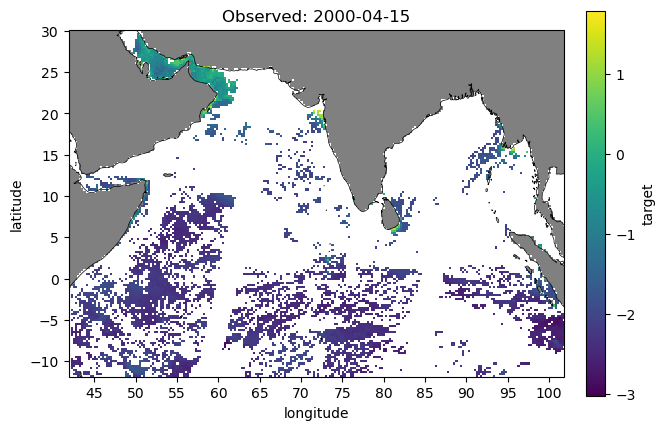

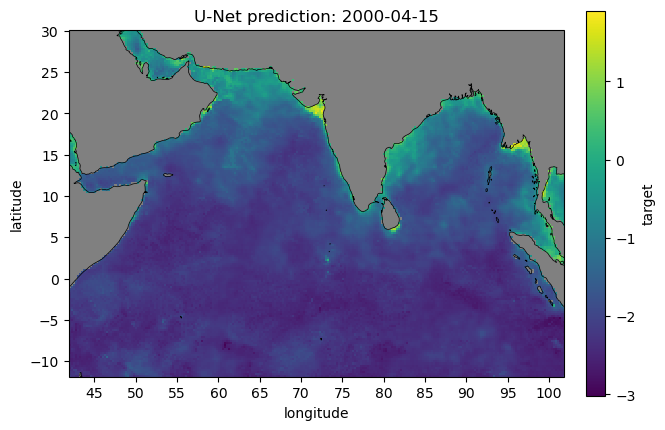

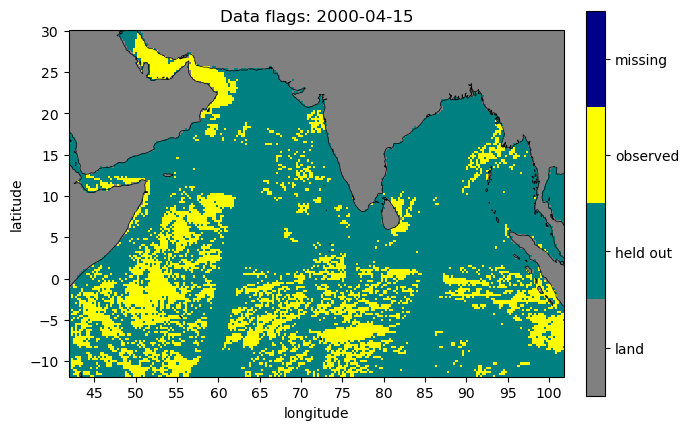

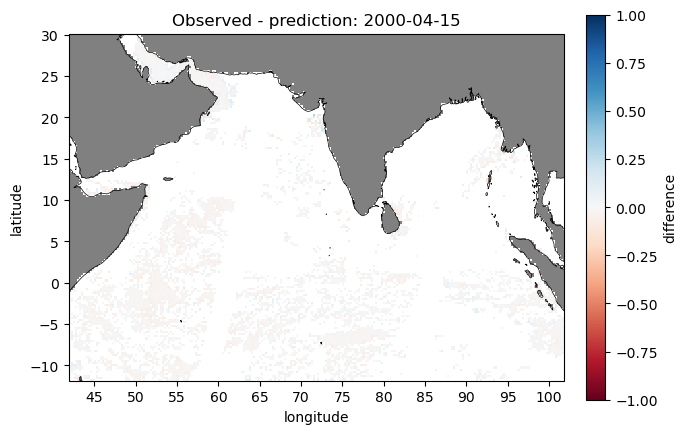

In [6]:
date = "2000-04-15"

viz.plot_observed(ds_std, metadata, date)
viz.plot_prediction(ds_std, model, metadata, date)
viz.plot_flags(ds_std, date)
viz.plot_difference(ds_std, model, metadata, date)

## Standard four-panel view

The composite calls the same individual panel functions and predicts only once.

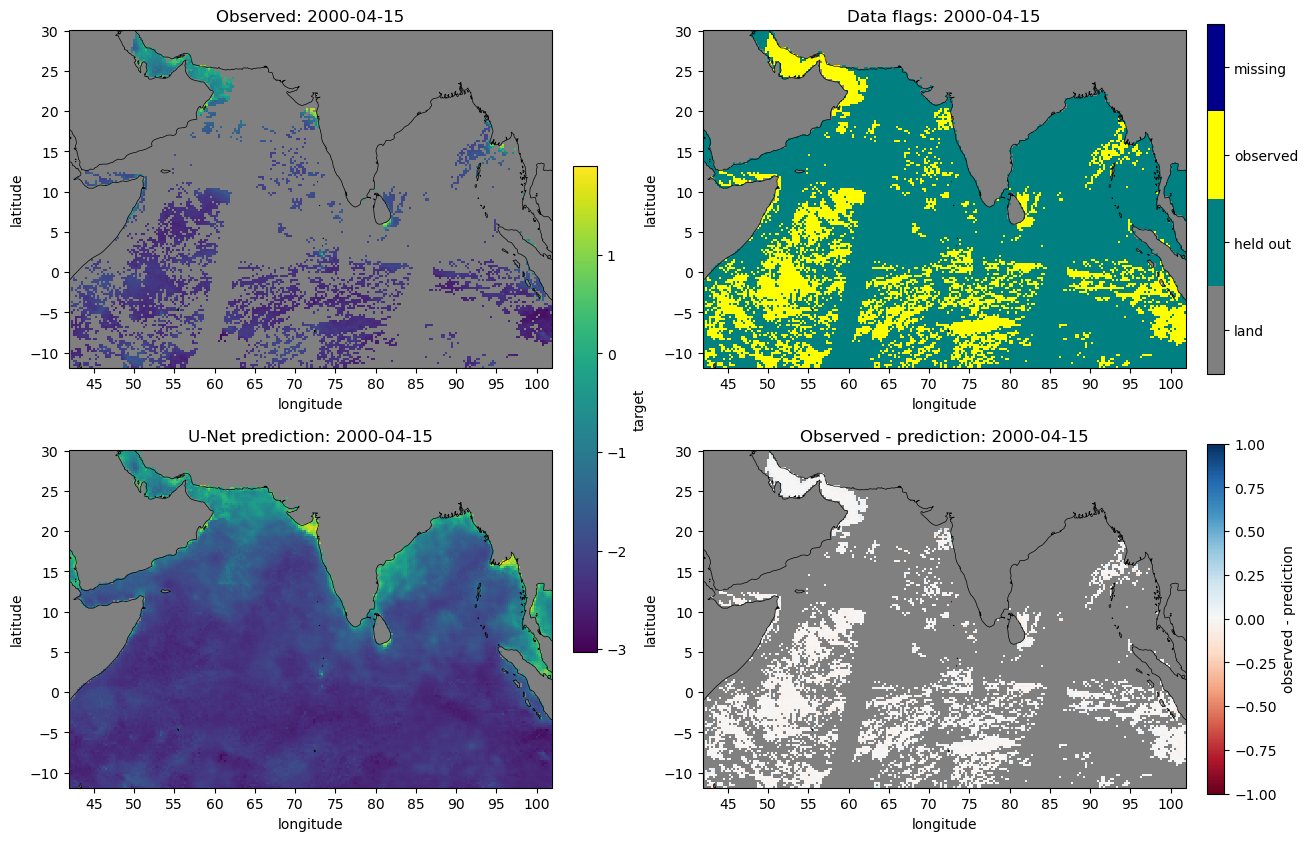

In [15]:
fig, axes = viz.plot_prediction_observed(
    ds_std,
    model,
    metadata,
    date,
    difference_limit=1.0,
)
plt.show()